In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from sklearn.ensemble import IsolationForest
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array

#Configuration
#Set the path to your main dataset folder
DATASET_PATH = r"C:\Users\USER\Desktop\AI Project PG 127\PG-127\data\FER_Custom_Dataset"

#Define the target image size
IMG_SIZE = (50, 50)


In [3]:
def load_initial_data(dataset_path):
    """Loads image filepaths and labels from the directory."""
    filepaths = []
    labels = []
    class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    label_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        for filename in os.listdir(class_dir):
            filepaths.append(os.path.join(class_dir, filename))
            labels.append(label_map[class_name])
    
    print(f"Found {len(filepaths)} images belonging to {len(class_names)} classes.")
    return filepaths, np.array(labels), class_names

#Execute Loading
filepaths, labels, class_names = load_initial_data(DATASET_PATH)


Found 43819 images belonging to 3 classes.


In [6]:
#Outlier Removal (using Isolation Forest on resized, grayscale images)
def remove_outliers(filepaths, labels, img_size):
    """Detects and removes outliers from the dataset based on image features."""
    flat_images = []
    valid_indices = []
    
    #First, read and resize all images to create a feature set
    for i, path in enumerate(tqdm(filepaths, desc="Preparing for Outlier Detection")):
        try:
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, img_size)
                flat_images.append(img.flatten())
                valid_indices.append(i)
        except Exception:
            continue
            
    flat_images = np.array(flat_images)
    
    #Train Isolation Forest
    iso_forest = IsolationForest(contamination='auto', random_state=42, n_jobs=-1)
    outlier_preds = iso_forest.fit_predict(flat_images)
    
    #Get the indices of inliers relative to the 'valid_indices' list
    inlier_mask = np.where(outlier_preds == 1)[0]
    
    #Map back to original filepaths and labels
    final_inlier_indices = [valid_indices[i] for i in inlier_mask]
    
    inlier_filepaths = [filepaths[i] for i in final_inlier_indices]
    inlier_labels = labels[final_inlier_indices]

    print(f"Original number of images: {len(filepaths)}")
    print(f"Number of outliers detected and removed: {len(filepaths) - len(inlier_filepaths)}")
    print(f"Number of images after cleaning: {len(inlier_filepaths)}")
    
    return inlier_filepaths, inlier_labels


#Run the function immediately after defining it
inlier_filepaths, inlier_labels = remove_outliers(filepaths, labels, IMG_SIZE)

#Show first few results as a quick sanity check
print("\nFirst 5 filepaths after cleaning:")
for fp in inlier_filepaths[:5]:
    print(fp)

print("\nFirst 5 labels after cleaning:", inlier_labels[:5])


Preparing for Outlier Detection: 100%|██████████| 43819/43819 [13:52<00:00, 52.61it/s] 


Original number of images: 43819
Number of outliers detected and removed: 9424
Number of images after cleaning: 34395

First 5 filepaths after cleaning:
C:\Users\USER\Desktop\AI Project PG 127\PG-127\data\FER_Custom_Dataset\Disappointed\100.jpg
C:\Users\USER\Desktop\AI Project PG 127\PG-127\data\FER_Custom_Dataset\Disappointed\1000.jpg
C:\Users\USER\Desktop\AI Project PG 127\PG-127\data\FER_Custom_Dataset\Disappointed\1002.jpg
C:\Users\USER\Desktop\AI Project PG 127\PG-127\data\FER_Custom_Dataset\Disappointed\1004.jpg
C:\Users\USER\Desktop\AI Project PG 127\PG-127\data\FER_Custom_Dataset\Disappointed\1014.jpg

First 5 labels after cleaning: [0 0 0 0 0]


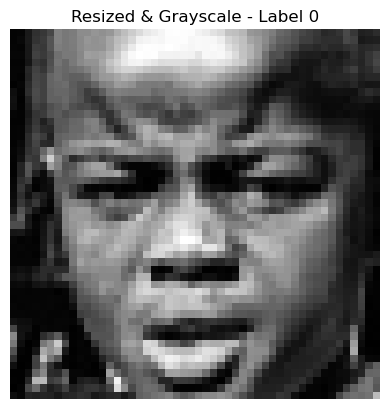

In [8]:
#Resizing and Grayscaling
def resize_and_grayscale(image, img_size):
    """Resizes and converts an image to grayscale."""
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.resize(gray_img, img_size)

#Test on one sample image
sample_idx = 0
sample_img = cv2.imread(inlier_filepaths[sample_idx])
resized_gray = resize_and_grayscale(sample_img, IMG_SIZE)

plt.imshow(resized_gray, cmap="gray")
plt.title(f"Resized & Grayscale - Label {inlier_labels[sample_idx]}")
plt.axis("off")
plt.show()



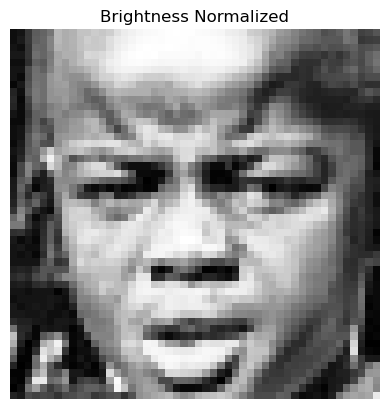

In [10]:
#Brightness Normalization
def apply_brightness_normalization(image):
    """Applies histogram equalization to a grayscale image."""
    return cv2.equalizeHist(image)

#Apply and show result
normalized_img = apply_brightness_normalization(resized_gray)

plt.imshow(normalized_img, cmap="gray")
plt.title("Brightness Normalized")
plt.axis("off")
plt.show()


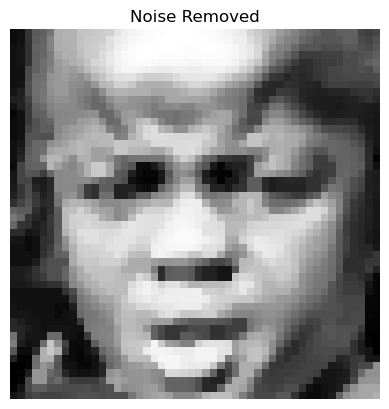

In [12]:
#Noise Removal
def apply_noise_removal(image):
    """Applies a median blur filter to an image."""
    return cv2.medianBlur(image, 3)

#Apply and show result
denoised_img = apply_noise_removal(normalized_img)

plt.imshow(denoised_img, cmap="gray")
plt.title("Noise Removed")
plt.axis("off")
plt.show()


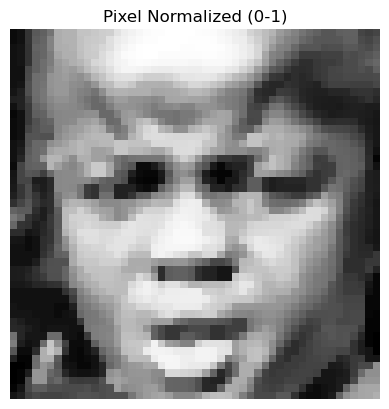

In [14]:
#Pixel Normalization
def apply_pixel_normalization(images):
    """Scales pixel values from [0, 255] to [0, 1]."""
    images_np = np.array(images, dtype=np.float32)
    return images_np / 255.0

#Apply and show result for single image
normalized_pixels = apply_pixel_normalization([denoised_img])[0]

plt.imshow(normalized_pixels, cmap="gray")
plt.title("Pixel Normalized (0-1)")
plt.axis("off")
plt.show()


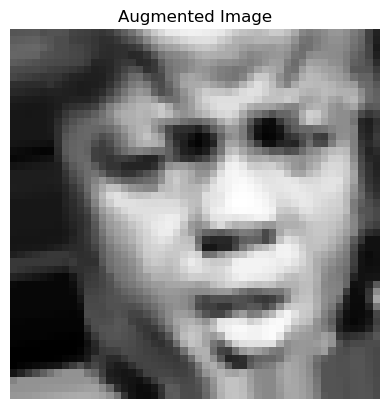

In [16]:
#Image Augmentation
def apply_augmentation(images, labels):
    """Generates augmented images to expand the dataset."""
    images = images.reshape(images.shape[0], images.shape[1], images.shape[2], 1)
    
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    augmented_images, augmented_labels = [], []
    
    for i in range(images.shape[0]):
        img = images[i]
        label = labels[i]
        aug_iter = datagen.flow(np.expand_dims(img, 0), batch_size=1)
        augmented_img = next(aug_iter)[0]
        
        augmented_images.append(augmented_img.squeeze())
        augmented_labels.append(label)
        
    return np.array(augmented_images), np.array(augmented_labels)

#Test on single image
aug_imgs, aug_labels = apply_augmentation(np.array([denoised_img]), np.array([inlier_labels[sample_idx]]))

plt.imshow(aug_imgs[0], cmap="gray")
plt.title("Augmented Image")
plt.axis("off")
plt.show()


In [20]:

#Output directory for processed images
PROCESSED_OUTPUT = r"C:\Users\USER\Desktop\AI Project PG 127\PG-127\results\outputs"
os.makedirs(PROCESSED_OUTPUT, exist_ok=True)

#Define your class names in order of labels
class_names = ['Disappointed', 'Interested', 'Neutral']

#Function to save images
def save_images(images, labels, output_dir, class_names):
    """
    Saves images to class-specific folders inside output_dir.
    
    images: np.array of shape (num_images, height, width)
    labels: array of integer labels
    class_names: list of class names corresponding to label indices
    """
    for i in tqdm(range(len(images)), desc="Saving images"):
        label = labels[i]
        class_name = class_names[label]
        class_folder = os.path.join(output_dir, class_name)
        os.makedirs(class_folder, exist_ok=True)
        
        #Save as PNG
        filename = f"{class_name}_{i}.png"
        filepath = os.path.join(class_folder, filename)
        
        #Convert pixel values to 0-255 if normalized
        img_to_save = (images[i] * 255).astype(np.uint8) if images[i].max() <= 1 else images[i]
        cv2.imwrite(filepath, img_to_save)

#Run the preprocessing pipeline and save
processed_images = []

for idx in tqdm(range(len(inlier_filepaths)), desc="Processing images"):
    img = cv2.imread(inlier_filepaths[idx])
    img = resize_and_grayscale(img, IMG_SIZE)
    img = apply_brightness_normalization(img)
    img = apply_noise_removal(img)
    processed_images.append(img)

processed_images = np.array(processed_images, dtype=np.float32)
#Normalize pixels to 0-1
processed_images_norm = apply_pixel_normalization(processed_images)

#Save processed images into class folders
save_images(processed_images_norm, inlier_labels, PROCESSED_OUTPUT, class_names)

print(f" All processed images saved in: {PROCESSED_OUTPUT}")


Saving images: 100%|██████████| 34395/34395 [02:15<00:00, 254.37it/s]

 All processed images saved in: C:\Users\USER\Desktop\AI Project PG 127\PG-127\results\outputs
